In [4]:
!pip install tensorflow
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install op

ERROR: Could not find a version that satisfies the requirement op (from versions: none)
ERROR: No matching distribution found for op


In [5]:
# ==========================================
# Bird vs Drone Classification Project
# Step 1 : Import Libraries
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.21.0


In [6]:
train_dir = r"C:\Users\Personal\Documents\object_detection\data\train"

val_dir = r"C:\Users\Personal\Documents\object_detection\data\val"

test_dir = r"C:\Users\Personal\Documents\object_detection\data\test"

In [7]:
print("Training Classes")

print(os.listdir(train_dir))

Training Classes
['bird', 'drone']


In [ ]:
#COUNT IMAGES

In [8]:
print("Training Images")

for folder in os.listdir(train_dir):

    path = os.path.join(train_dir, folder)

    print(folder, ":", len(os.listdir(path)))

Training Images
bird : 1414
drone : 1248


In [ ]:
#VALIDATION

In [9]:
print("\nValidation Images")

for folder in os.listdir(val_dir):

    path = os.path.join(val_dir, folder)

    print(folder, ":", len(os.listdir(path)))


Validation Images
bird : 217
drone : 225


In [ ]:
#TESTING 

In [10]:
print("\nTesting Images")

for folder in os.listdir(test_dir):

    path = os.path.join(test_dir, folder)

    print(folder, ":", len(os.listdir(path)))


Testing Images
bird : 121
drone : 94


In [ ]:
#Show Sample Images

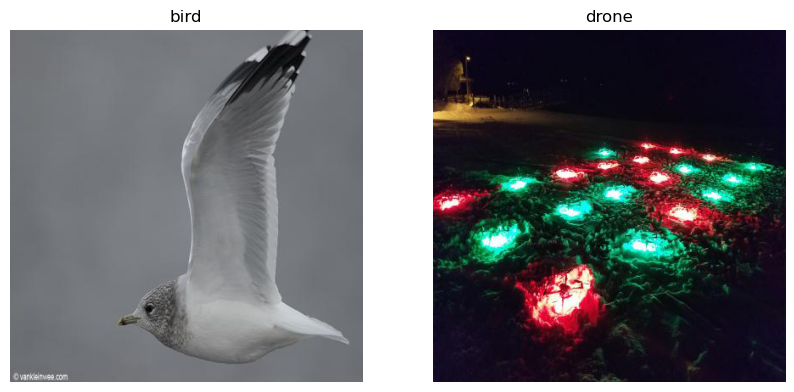

In [11]:
classes = os.listdir(train_dir)

plt.figure(figsize=(10,5))

for i, cls in enumerate(classes):

    folder = os.path.join(train_dir, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    image = Image.open(image_path)

    plt.subplot(1,2,i+1)

    plt.imshow(image)

    plt.title(cls)

    plt.axis("off")

plt.show()

In [ ]:
#Class Distribution

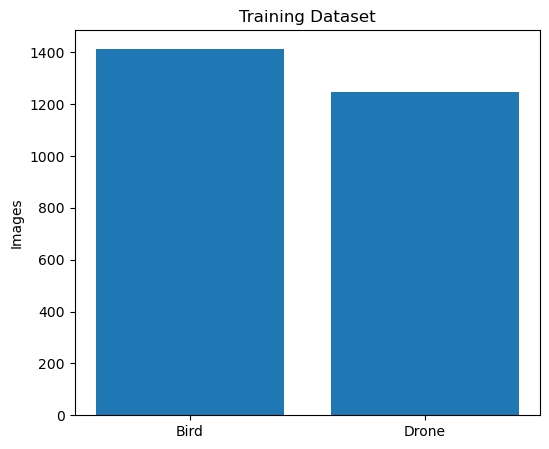

In [12]:
bird = len(os.listdir(os.path.join(train_dir,"bird")))

drone = len(os.listdir(os.path.join(train_dir,"drone")))

plt.figure(figsize=(6,5))

plt.bar(["Bird","Drone"],[bird,drone])

plt.title("Training Dataset")

plt.ylabel("Images")

plt.show()

In [ ]:
#Check Image Sizes

In [13]:
sizes=[]

for cls in classes:

    folder=os.path.join(train_dir,cls)

    for image in os.listdir(folder):

        img=Image.open(os.path.join(folder,image))

        sizes.append(img.size)

print("First 10 Image Sizes")

print(sizes[:10])

First 10 Image Sizes
[(416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416), (416, 416)]


In [ ]:
#Data Augmentation

In [14]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"

)

validation_datagen = ImageDataGenerator(

    rescale=1./255

)

test_datagen = ImageDataGenerator(

    rescale=1./255

)

In [ ]:
#Load Dataset

In [15]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary"

)

validation_generator = validation_datagen.flow_from_directory(

    val_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode="binary"

)

test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(224,224),

    batch_size=32,

    shuffle=False,

    class_mode="binary"

)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [ ]:
#Check Class Index

In [16]:
print(train_generator.class_indices)

{'bird': 0, 'drone': 1}


In [ ]:
#Display Augmented Images

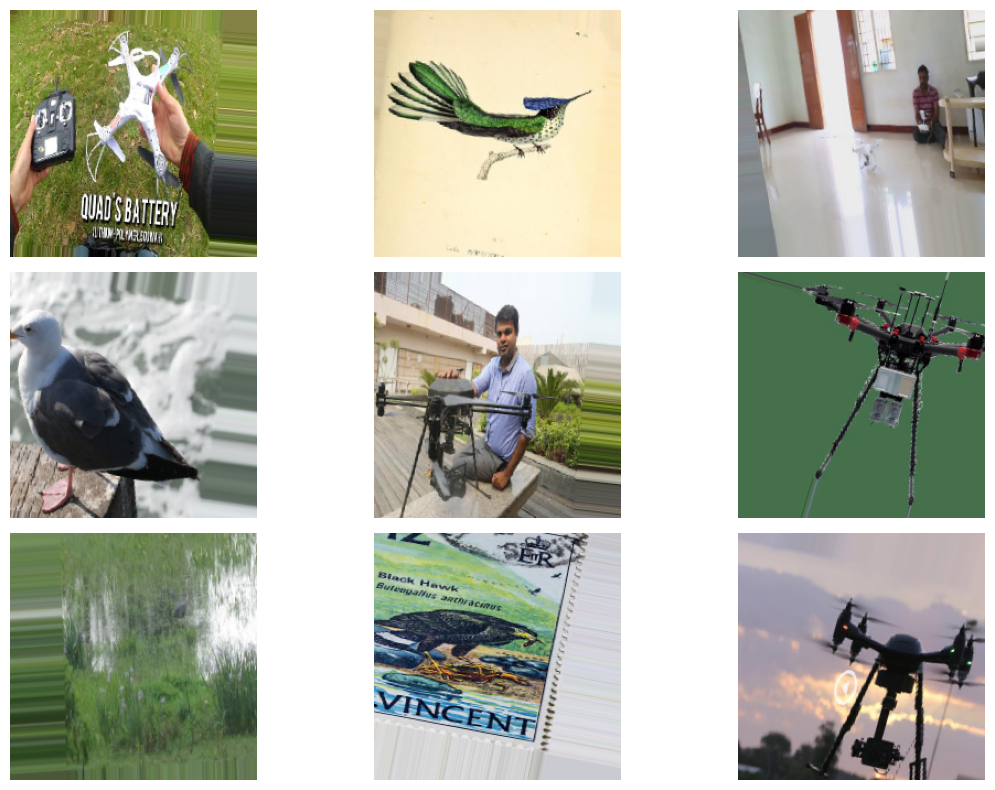

In [17]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
#TRAIN EACcustom_cnn

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [ ]:
#Build the Custom CNN Mode

In [19]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Block 4
model.add(Conv2D(256, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

C:\Users\Personal\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Display Model Summary

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,265,729 (73.49 MB)

 Trainable params: 19,264,769 (73.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
#Compile the Model

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
#Create Callbacks

In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "custom_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [ ]:
#Train the Model

In [23]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6197 - loss: 11.8874
Epoch 1: val_accuracy improved from None to 0.50905, saving model to custom_cnn.keras

Epoch 1: finished saving model to custom_cnn.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.6382 - loss: 8.5287 - val_accuracy: 0.5090 - val_loss: 6.6994
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6507 - loss: 4.0300
Epoch 2: val_accuracy did not improve from 0.50905
84/84 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.6627 - loss: 2.7745 - val_accuracy: 0.3620 - val_loss: 1.7593
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7136 - loss: 0.7621
Epoch 3: val_accuracy improved from 0.50905 to 0.51810, saving model to custom_cnn.keras

Epoch 3: finished saving model to custom_cnn.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.7186 - loss: 0.6897 - val_accuracy: 0.5181 - val_loss: 2.0416
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7483 - lo

In [24]:
model.evaluate(test_generator)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.8837 - loss: 0.3795


[0.37951287627220154, 0.8837209343910217]

In [ ]:
#Save the Model

In [25]:
model.save("bird_drone_custom_cnn.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
#Plot Accuracy

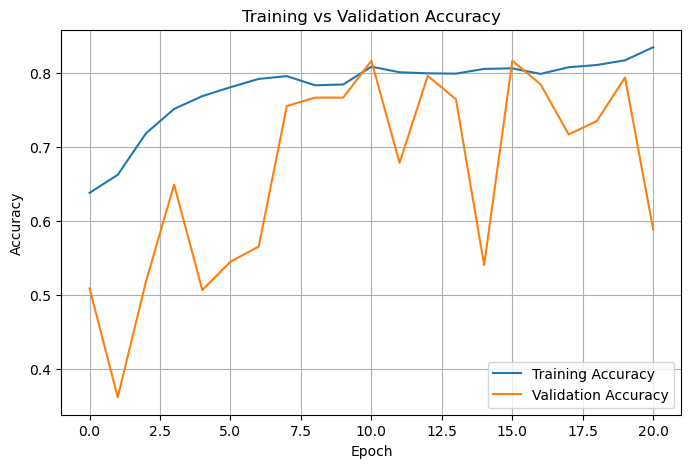

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Plot Loss

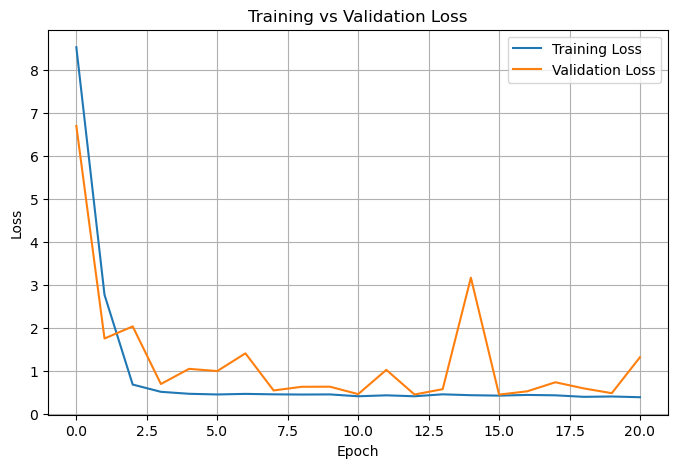

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#Generate Predictions

In [28]:
predictions = model.predict(test_generator)

print(predictions[:10])

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step
[[5.9159583e-10]
 [1.9290958e-02]
 [2.5403281e-06]
 [1.6718237e-01]
 [2.3176183e-01]
 [3.9472076e-01]
 [4.1285650e-05]
 [2.5211012e-01]
 [2.2530939e-01]
 [1.0202133e-02]]


In [37]:
predicted_classes = (predictions > 0.5).astype(int)

In [ ]:
#Display Actual Classes

In [38]:
true_classes = test_generator.classes

print(true_classes[:10])

[0 0 0 0 0 0 0 0 0 0]


In [ ]:
#Calculate Accuracy

In [32]:
predictions = model.predict(test_generator)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 548ms/step


In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(true_classes, predicted_classes)

print("Accuracy:", accuracy)

Accuracy: 0.8837209302325582


In [ ]:
#Precision

In [40]:
from sklearn.metrics import precision_score

precision = precision_score(true_classes, predicted_classes)

print("Precision :", precision)

Precision : 0.896551724137931


In [ ]:
#Recall

In [41]:
from sklearn.metrics import recall_score

recall = recall_score(true_classes, predicted_classes)

print("Recall :", recall)

Recall : 0.8297872340425532


In [ ]:
#F1-Score

In [42]:
from sklearn.metrics import f1_score

f1 = f1_score(true_classes, predicted_classes)

print("F1 Score :", f1)

F1 Score : 0.861878453038674


In [ ]:
#Classification Report

In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["Bird", "Drone"]
))

              precision    recall  f1-score   support

        Bird       0.88      0.93      0.90       121
       Drone       0.90      0.83      0.86        94

    accuracy                           0.88       215
   macro avg       0.89      0.88      0.88       215
weighted avg       0.88      0.88      0.88       215



In [ ]:
# PLOT Confusion Matrix

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

[[112   9]
 [ 16  78]]


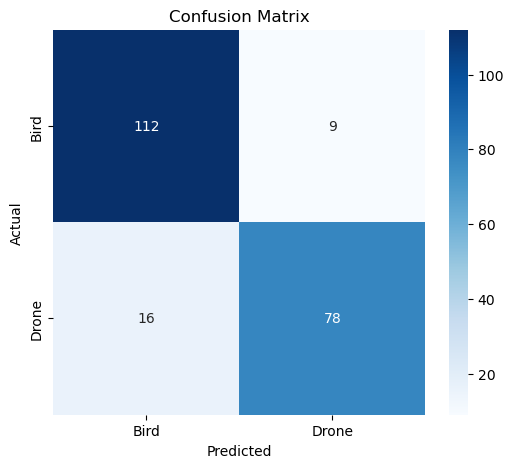

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bird","Drone"],
    yticklabels=["Bird","Drone"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
#MobileNetV2

In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model

In [ ]:
#Load Pretrained Model

In [48]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [ ]:
#Freeze Base Model

In [49]:
base_model.trainable = False

In [ ]:
#Add Global Average Pooling

In [50]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

In [ ]:
#Add Dense Layer

In [51]:
x = Dense(
    256,
    activation='relu'
)(x)

In [ ]:
#Add Dropout

In [52]:
x = Dropout(0.5)(x)

In [ ]:
#Output Layer

In [53]:
predictions = Dense(
    1,
    activation='sigmoid'
)(x)

In [ ]:
#Create Model

In [54]:
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
#Display Model Summary

In [55]:
model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#Compile the MobileNetV2 Model

In [56]:
import tensorflow as tf

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
#Create Callbacks

In [57]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
#EarlyStopping

In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
#ModelCheckpoint

In [59]:
checkpoint = ModelCheckpoint(
    "mobilenetv2.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

In [ ]:
#Reduce Learning Rate

In [60]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
#Train the MobileNetV2 Model

In [61]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8707 - loss: 0.3059 - precision: 0.8686 - recall: 0.8451
Epoch 1: val_accuracy improved from None to 0.95928, saving model to mobilenetv2.keras

Epoch 1: finished saving model to mobilenetv2.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9260 - loss: 0.1920 - precision: 0.9255 - recall: 0.9159 - val_accuracy: 0.9593 - val_loss: 0.1011 - val_precision: 0.9442 - val_recall: 0.9778 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9522 - loss: 0.1104 - precision: 0.9486 - recall: 0.9531
Epoch 2: val_accuracy improved from 0.95928 to 0.96833, saving model to mobilenetv2.keras

Epoch 2: finished saving model to mobilenetv2.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9523 - loss: 0.1116 - precision: 0.9473 - recall: 0.9511 - val_accuracy: 0.9683 - val_loss: 0.1056 - val_precision: 0.9953 - val_recall: 0.9422 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━

In [ ]:
#Evaluate the Model

In [62]:
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)

print("=================================")
print("Test Loss      :", test_loss)
print("Test Accuracy  :", test_accuracy)
print("Test Precision :", test_precision)
print("Test Recall    :", test_recall)

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 759ms/step - accuracy: 0.9674 - loss: 0.0676 - precision: 0.9677 - recall: 0.9574
Test Loss      : 0.0675644502043724
Test Accuracy  : 0.9674418568611145
Test Precision : 0.9677419066429138
Test Recall    : 0.957446813583374


In [63]:
model.save("bird_drone_mobilenetv2.keras")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


In [ ]:
#Model Comparison

In [64]:
import pandas as pd

In [ ]:
#Create Comparison Table

In [65]:
comparison = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "MobileNetV2"
    ],

    "Accuracy":[
        88.00,
        96.74
    ],

    "Precision":[
        88.00,
        96.77
    ],

    "Recall":[
        88.00,
        95.74
    ]

})

comparison

,Model,Accuracy,Precision,Recall
0,Custom CNN,88.00,88.00,88.00
1,MobileNetV2,96.74,96.77,95.74


In [ ]:
#Display Comparison

In [66]:
print(comparison)

         Model  Accuracy  Precision  Recall
0   Custom CNN     88.00      88.00   88.00
1  MobileNetV2     96.74      96.77   95.74


In [ ]:
#Plot Accuracy Comparison

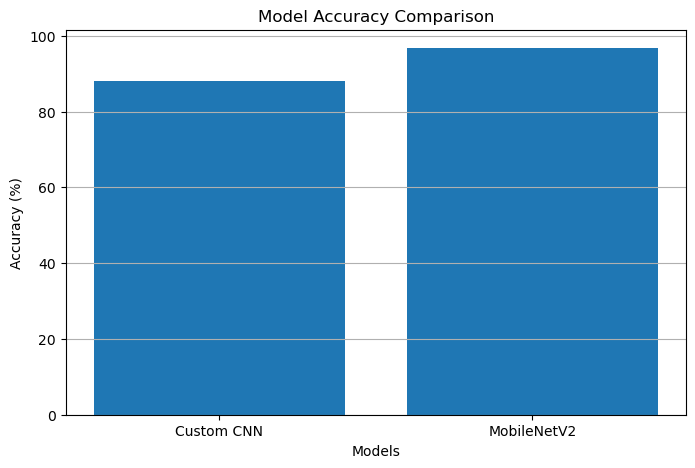

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.grid(axis='y')

plt.show()

In [ ]:
#Best Model

In [68]:
best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print(best_model)

Model        MobileNetV2
Accuracy           96.74
Precision          96.77
Recall             95.74
Name: 1, dtype: object


In [69]:
model.save("best_bird_drone_model.keras")

print("Best model saved successfully!")

Best model saved successfully!
